
<a href="https://colab.research.google.com/github/CienciaDatosUdea/005_CCA_Estudiantes/blob/main/Laboratorios/12_Lab_PinnsI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import numpy as np
import matplotlib.pylab as plt
import plotly.graph_objects as go
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display


#Diferenciación automática

In [2]:
def suma(a, da, b, db):
  return a+b, da+db

def producto(a, da, b, db):
  return a*b, a*db + da*b

def division(a, da, b, db):
  return a/b, (b*da - a*db)/(b**2)

def seno(a, da):
  return np.cos(a), da*np.cos(a)

def coseno(a, da):
  return -np.sin(a), -da*np.cos(a)


def tanhiperbolica(a, da):
    valor = np.tanh(a)
    return valor, (1 - valor**2)*da

Computemos la deriva de:

$f(x) = x^2$


$f(x) = (2x+1)^2$

In [3]:
x = 2.2

In [4]:
derivadaX = producto(x, 1, x, 1)
derivadaX

(4.840000000000001, 4.4)

In [5]:
u, du = producto(2, 0, x, 1)
c, dc = suma(u, du, 1, 0)
producto(c, dc, c, dc)

(29.160000000000004, 21.6)

In [6]:
x = np.linspace(0, 2*np.pi)

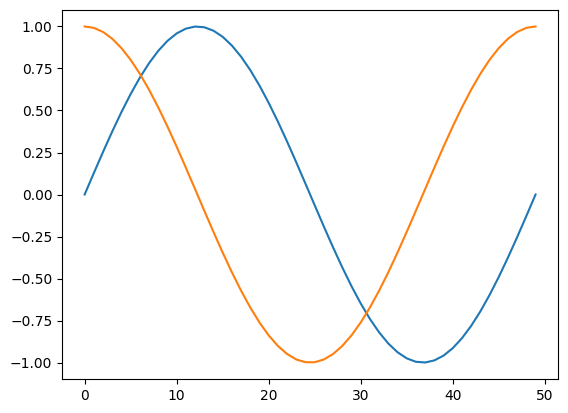

In [7]:
plt.plot(np.sin(x))
plt.plot(seno(x, 1)[0])

$
f(x)=\sin\!\bigl(\cos(x^2)\bigr),
$

$
u=x^2,\qquad u'=2x,
$

$
v=\cos(u),\qquad v'=-\sin(u)\,u',
$


$
f=\sin(v),\qquad f'=\cos(v)\,v'.
$


$
f'(x)=-2x\,\sin(x^2)\,\cos\!\bigl(\cos(x^2)\bigr).
$

In [8]:
x = np.linspace(0, 2*np.pi, 10000)
u, du = producto(x, 1, x, 1)
c, dc = coseno(u, du)
r, dr = seno(c, dc)

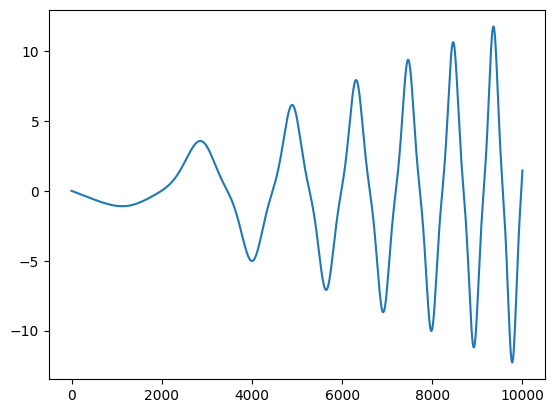

In [9]:
plt.plot(dr)

Supongamos que tenemos dos conectadas y queremos computar una diferenciacion automática cuyas funciones de activación son tanh:

\begin{equation}
\frac{da_2}{dx}
=
\frac{da_2}{dz_2}
\frac{dz_2}{da_1}
\frac{da_1}{dz_1}
\frac{dz_1}{dx}
=
(1-\tanh Z_2^2)\,w_2\,(1-\tanh Z_1^2)\,w_1.
\end{equation}



In [10]:
x = 0.8
w = 0.1
b = 0.1

z = w*x + b
a1 = np.tanh(z)

z2 = w*a1 + b
a2 = np.tanh(z2)

derivada = (1-(np.tanh( z2))**2) * (1-(np.tanh( z))**2)*w**2
derivada

np.float64(0.009549719627467191)

In [11]:
t1, dt1 = producto(w, 0, x, 1)
z, dz = suma(t1, dt1, b, 0)
a1, da1 = tanhiperbolica(z, dz)

t2, dt2 = producto(w, 0, a1, da1)
z2, dz2 = suma(t2, dt2, b, 0)
a2, da2 = tanhiperbolica(z2, dz2)
a2, da2




(np.float64(0.11726608605144122), np.float64(0.009549719627467191))

In [12]:
def dneurona(x, dx, w, b):
  t1, dt1 = producto(w, 0, x, dx)
  z, dz = suma(t1, dt1, b, 0)
  a1, da1 = tanhiperbolica(z, dz)
  return a1, da1

In [13]:
a1, da1 = dneurona(x, 1, w, b)
a2, da2 = dneurona(a1, da1, w, b)
a2, da2

(np.float64(0.11726608605144122), np.float64(0.009549719627467191))

### Difusión de calor en una placa cuadrada

Considere una placa homogénea de lado $L$, sin fuentes internas
de calor y con temperatura uniforme a través de su espesor.
Su difusividad térmica es constante:

$$
\alpha=\frac{k}{\rho c_p},
$$

donde $k$ es la conductividad térmica, $\rho$ la densidad y
$c_p$ el calor específico.

Determine la temperatura $T(x,y,t)$ en el dominio
$(x,y)\in(0,L)^2$, para $t>0$, mediante la ecuación de calor:

$$
\frac{\partial T}{\partial t}
=
\alpha\left(
\frac{\partial^2T}{\partial x^2}
+
\frac{\partial^2T}{\partial y^2}
\right).
$$

Los cuatro bordes permanecen a temperatura constante $T_b$:

$$
T(0,y,t)=T(L,y,t)=T(x,0,t)=T(x,L,t)=T_b.
$$

La temperatura inicial es:

$$
T(x,y,0)=T_b+\Delta T
\sin\left(\frac{\pi x}{L}\right)
\sin\left(\frac{\pi y}{L}\right),
$$

donde $\Delta T>0$ es la diferencia inicial entre la temperatura
del centro y la de los bordes.

Aproximar $T(x,y,t)$ mediante una PINN,
minimizando el residual de la ecuación y los errores en las
condiciones iniciales y de frontera. Comparar el resultado
con la solución analítica:

$$
T(x,y,t)=T_b+\Delta T
e^{-2\alpha\pi^2t/L^2}
\sin\left(\frac{\pi x}{L}\right)
\sin\left(\frac{\pi y}{L}\right).
$$

In [ ]:
Lx = 1.0       # Longitud en x [m]
Ly = 1.0       # Longitud en y [m]
Tb = 300     # Temperatura fija de los bordes [°C]
delta_T = 100.0 # Diferencia inicial centro-bordes [°C]

alpha = 1e-4  # Difusividad térmica [m²/s]
params = {'Lx': Lx, 'Ly': Ly, 'Tb': Tb, "delta":delta_T ,'alpha': alpha}

In [ ]:
def T(x, y, t, **params):

  Lx = params['Lx']
  Ly = params['Ly']
  Tb = params['Tb']
  alpha = params['alpha']
  u = np.sin(np.pi*x/Lx)*np.sin(np.pi*y/Ly)
  return Tb + delta_T* np.exp(-2*alpha*np.pi**2*t/(Lx*Ly))*u


In [ ]:
nx, ny = 30, 30
tiempo_final = 500.0

x = np.linspace(0, params["Lx"], nx)
y = np.linspace(0, params["Ly"], ny)
dx = x[1] - x[0]
dy = y[1] - y[0]

# Límite de estabilidad para diferencias finitas con Euler explícito
dt_max = 1 / (
    2 * params["alpha"] * (1 / dx**2 + 1 / dy**2)
)
# Margen de seguridad del 10 %
nt = int(np.ceil(tiempo_final / (0.9 * dt_max))) + 1

t = np.linspace(0, tiempo_final, nt)
dt = t[1] - t[0]
X, Y = np.meshgrid(x, y, indexing="ij")
nx, ny, nt = len(x), len(y), len(t)
Temperatura = np.zeros((nt,nx, ny))

In [ ]:
import numpy as np
import plotly.graph_objects as go


def graficar_planos(
    Temperatura, Lx, Ly,
    tiempos=None,
    n_planos=5,
    opacidad=0.5
):
    nt, nx, ny = Temperatura.shape

    x = np.linspace(0, Lx, nx)
    y = np.linspace(0, Ly, ny)
    X, Y = np.meshgrid(x, y, indexing="ij")

    titulo_t = "Tiempo [s]" if tiempos is not None else "Índice de tiempo"
    tiempos = np.arange(nt) if tiempos is None else np.asarray(tiempos)

    # Seleccionar pocos tiempos, incluyendo el primero y el último.
    indices = np.unique(
        np.linspace(0, nt - 1, min(n_planos, nt), dtype=int)
    )

    # Escala de colores común.
    Tmin = float(np.nanmin(Temperatura))
    Tmax = float(np.nanmax(Temperatura))

    if Tmin == Tmax:
        Tmin -= 0.5
        Tmax += 0.5

    fig = go.Figure()

    for j, k in enumerate(indices):
        fig.add_trace(go.Surface(
            x=np.full(X.shape, tiempos[k], dtype=float),
            y=X,
            z=Y,
            surfacecolor=Temperatura[k],
            colorscale="Jet",
            cmin=Tmin,
            cmax=Tmax,
            opacity=opacidad,
            showscale=(j == 0),
            colorbar=dict(title="Temperatura [°C]"),
            lighting=dict(ambient=1, diffuse=0, specular=0),
            name=f"Temperatura[{k}]",
            hovertemplate=(
                "Tiempo / índice = %{x:.3f}<br>"
                "x = %{y:.3f} m<br>"
                "y = %{z:.3f} m<br>"
                "T = %{surfacecolor:.2f} °C"
                "<extra>%{fullData.name}</extra>"
            )
        ))

    fig.update_layout(
        height=650,
        scene=dict(
            xaxis_title=titulo_t,
            yaxis_title="x [m]",
            zaxis_title="y [m]",
            aspectmode="manual",
            aspectratio=dict(x=1.6, y=1, z=Ly / Lx),
            camera=dict(eye=dict(x=-1.7, y=-1.7, z=0.8))
        ),
        margin=dict(l=0, r=0, b=0, t=30)
    )

    return fig

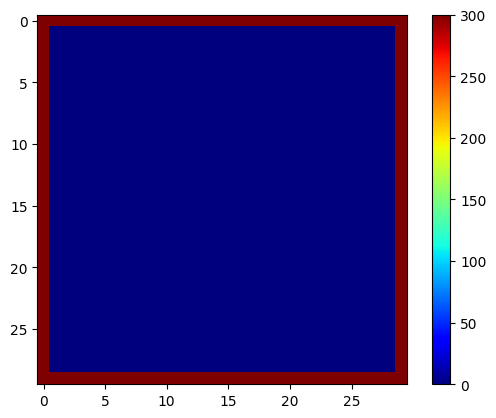

In [ ]:
fig = graficar_planos(
    Temperatura, Lx, Ly,
    n_planos=10,
    opacidad=0.5
)
fig.show()

(188, 30, 30)

188

In [ ]:

n_frames =len(Temperatura)# min(100), Temperatura.shape[0])

fig, ax = plt.subplots(figsize=(6, 5))

imagen = ax.imshow(
    Temperatura[0],
    cmap="jet",
    vmin=np.nanmin(Temperatura[:n_frames]),
    vmax=np.nanmax(Temperatura[:n_frames])
)

fig.colorbar(imagen, ax=ax, label="Temperatura [°C]")
titulo = ax.set_title("Temperatura[0]")

def actualizar(i):
    imagen.set_data(Temperatura[i])
    titulo.set_text(f"Temperatura[{i}]")
    return imagen, titulo

animacion = FuncAnimation(
    fig,
    actualizar,
    frames=n_frames,
    interval=1,
    repeat=True
)

plt.close(fig)
display(HTML(animacion.to_jshtml()))